### Assignment: Dimensionality Reduction and Image Reconstruction with PCA and Kernel PCA **[20 points]**

## Objective
The goal of this assignment is for you to explore dimensionality reduction using **Principal Component Analysis (PCA)** and **Kernel PCA**, and apply these techniques to **image reconstruction**. You will visualize how much information is preserved or lost with reduced dimensions, and compare linear vs. nonlinear methods.

---

## Part 1: Dataset Selection and Preprocessing

You will use the **Olivetti Faces Dataset** from `sklearn.datasets`. This dataset consists of 400 grayscale images (64x64) of faces, ideal for visualizing PCA-based reconstruction.

```python
from sklearn.datasets import fetch_olivetti_faces
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data  # shape (400, 4096)
images = faces.images  # shape (400, 64, 64)

# Visualize some original images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(images[i], cmap='gray')
    ax.axis('off')
plt.suptitle('Original Olivetti Faces')
plt.show()
```

---

## Part 2: PCA and Image Reconstruction

### Task:
- Apply PCA to reduce the image dimensionality.
- Reconstruct images from a reduced number of components (e.g., 10, 50, 100).
- Visualize and compare reconstructed images with the originals.

```python
from sklearn.decomposition import PCA

# Choose number of components
components_list = [10, 50, 100]
reconstructed_images = []

for n_components in components_list:
    pca = PCA(n_components=n_components, whiten=True, random_state=42)
    X_pca = pca.fit_transform(X)
    X_reconstructed = pca.inverse_transform(X_pca)
    reconstructed_images.append(X_reconstructed)

# Visualize reconstructions
fig, axes = plt.subplots(len(components_list), 5, figsize=(10, 6))
for i, n_components in enumerate(components_list):
    for j in range(5):
        axes[i, j].imshow(reconstructed_images[i][j].reshape(64, 64), cmap='gray')
        axes[i, j].axis('off')
    axes[i, 0].set_ylabel(f"{n_components} PCs")
plt.suptitle('Image Reconstruction with PCA')
plt.show()
```

---

## Part 3: Kernel PCA and Nonlinear Reconstruction

### Task:
- Apply **Kernel PCA** with different kernels (e.g., RBF, polynomial).
- Reconstruct the images from reduced representations (approximate inverse).
- Compare the quality with standard PCA.

```python
from sklearn.decomposition import KernelPCA

# Kernel PCA with RBF kernel
kpca = KernelPCA(n_components=100, kernel='rbf', fit_inverse_transform=True, gamma=0.01, random_state=42)
X_kpca = kpca.fit_transform(X)
X_kpca_reconstructed = kpca.inverse_transform(X_kpca)

# Visualize Kernel PCA reconstructions
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    axes[i].imshow(X_kpca_reconstructed[i].reshape(64, 64), cmap='gray')
    axes[i].axis('off')
plt.suptitle('Image Reconstruction with Kernel PCA (RBF)')
plt.show()
```

---

## Part 4: Questions & Analysis

### Write a brief report discussing:
1. How does the reconstruction quality vary with the number of principal components?
2. How does Kernel PCA compare to standard PCA in capturing nonlinear structures?
3. Which method better preserves identity and facial features at low dimensionality?
4. What are the trade-offs between PCA and Kernel PCA in terms of computation and interpretability?

---

## Deliverables
- A complete Jupyter notebook with:
  - Your code for PCA and Kernel PCA-based image reconstruction
  - Visualizations of original and reconstructed images
  - Your short written answers to the analysis questions
- Submit the notebook as both `.ipynb` and `.html` files.

---

## Hints
- You may use `whiten=True` in PCA to normalize components.
- Try adjusting `gamma` in Kernel PCA (for RBF kernel) to see its effect on reconstruction quality.
- Test with a small number of components (e.g., 10 or 20) to better appreciate the differences.


Part 1: Dataset Selection and Preprocessing

In [2]:
from sklearn.datasets import fetch_olivetti_faces
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
faces = fetch_olivetti_faces(shuffle=True, random_state=42)

X = faces.data        # shape: (400, 4096)
images = faces.images # shape: (400, 64, 64)

print("Data shape:", X.shape)
print("Image shape:", images.shape)

Data shape: (400, 4096)
Image shape: (400, 64, 64)


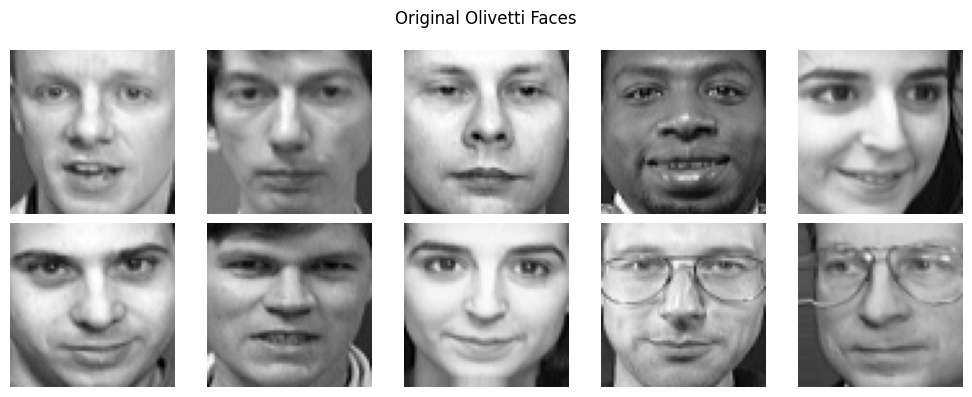

In [3]:
# Visualize some original images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(images[i], cmap='gray')
    ax.axis('off')

plt.suptitle('Original Olivetti Faces')
plt.tight_layout()
plt.show()

Part 2: PCA and Image Reconstruction

In [4]:
from sklearn.decomposition import PCA

components_list = [10, 50, 100]
reconstructed_images = []
explained_variances = []

for n_components in components_list:
    pca = PCA(n_components=n_components, whiten=True, random_state=42)
    
    X_pca = pca.fit_transform(X)
    
    X_reconstructed = pca.inverse_transform(X_pca)
    
    reconstructed_images.append(X_reconstructed)
    explained_variances.append(np.sum(pca.explained_variance_ratio_))
    
    print(f"{n_components} components preserve {np.sum(pca.explained_variance_ratio_):.4f} of variance")

10 components preserve 0.6563 of variance
50 components preserve 0.8736 of variance
100 components preserve 0.9349 of variance


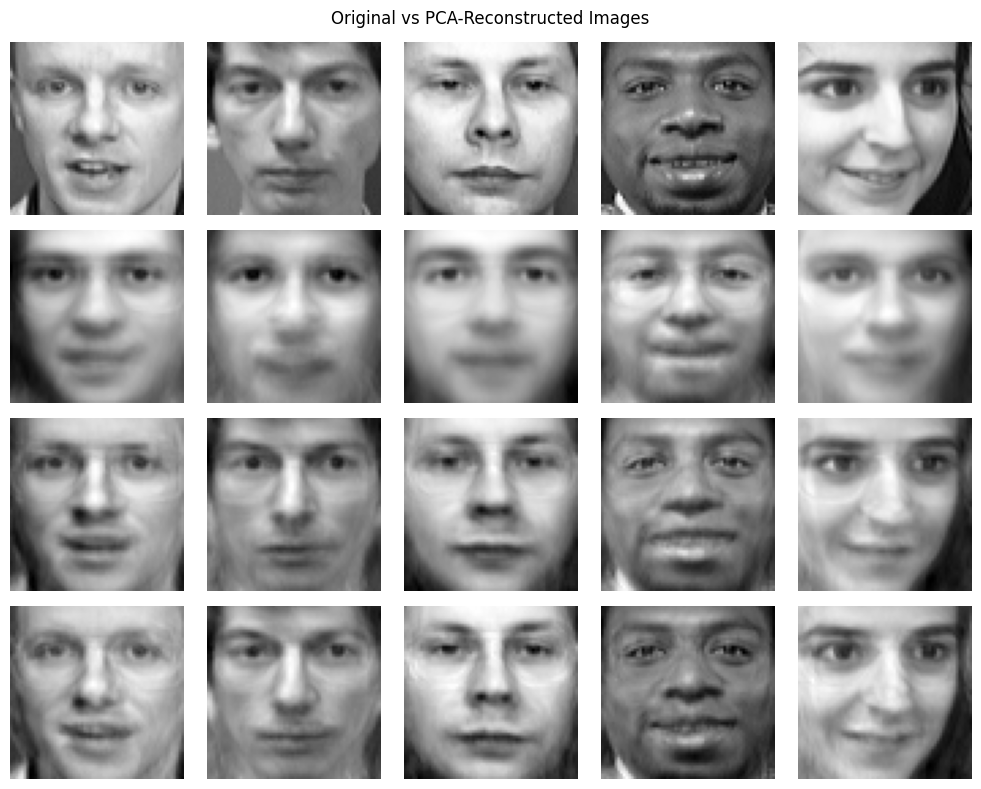

In [5]:
fig, axes = plt.subplots(len(components_list) + 1, 5, figsize=(10, 8))

for j in range(5):
    axes[0, j].imshow(images[j], cmap='gray')
    axes[0, j].axis('off')
axes[0, 0].set_ylabel("Original")

for i, n_components in enumerate(components_list):
    for j in range(5):
        axes[i + 1, j].imshow(reconstructed_images[i][j].reshape(64, 64), cmap='gray')
        axes[i + 1, j].axis('off')
    axes[i + 1, 0].set_ylabel(f"{n_components} PCs")

plt.suptitle('Original vs PCA-Reconstructed Images')
plt.tight_layout()
plt.show()

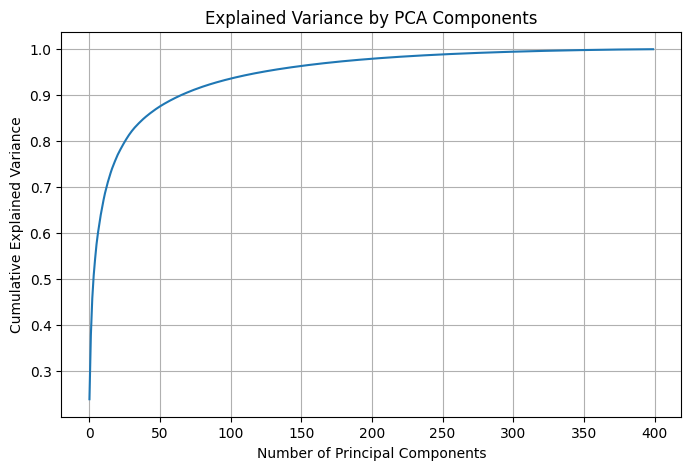

10 components preserve 0.6563 of variance
20 components preserve 0.7634 of variance
50 components preserve 0.8738 of variance
100 components preserve 0.9354 of variance
200 components preserve 0.9791 of variance


In [6]:
pca_full = PCA(random_state=42)
pca_full.fit(X)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)
plt.show()

for n in [10, 20, 50, 100, 200]:
    print(f"{n} components preserve {cumulative_variance[n-1]:.4f} of variance")

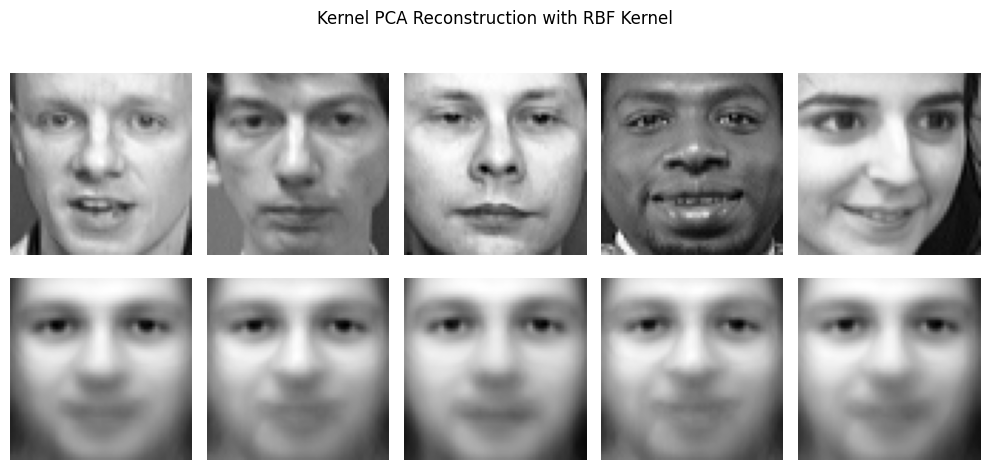

In [11]:
from sklearn.decomposition import KernelPCA

kpca_rbf = KernelPCA(
    n_components=100,
    kernel='rbf',
    fit_inverse_transform=True,
    gamma=0.01,
    random_state=42
)

X_kpca_rbf = kpca_rbf.fit_transform(X)
X_kpca_rbf_reconstructed = kpca_rbf.inverse_transform(X_kpca_rbf)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for j in range(5):
    axes[0, j].imshow(images[j], cmap='gray')
    axes[0, j].axis('off')

axes[0, 0].set_ylabel("Original")

for j in range(5):
    axes[1, j].imshow(X_kpca_rbf_reconstructed[j].reshape(64, 64), cmap='gray')
    axes[1, j].axis('off')

axes[1, 0].set_ylabel("RBF KPCA")

plt.suptitle('Kernel PCA Reconstruction with RBF Kernel')
plt.tight_layout()
plt.show()

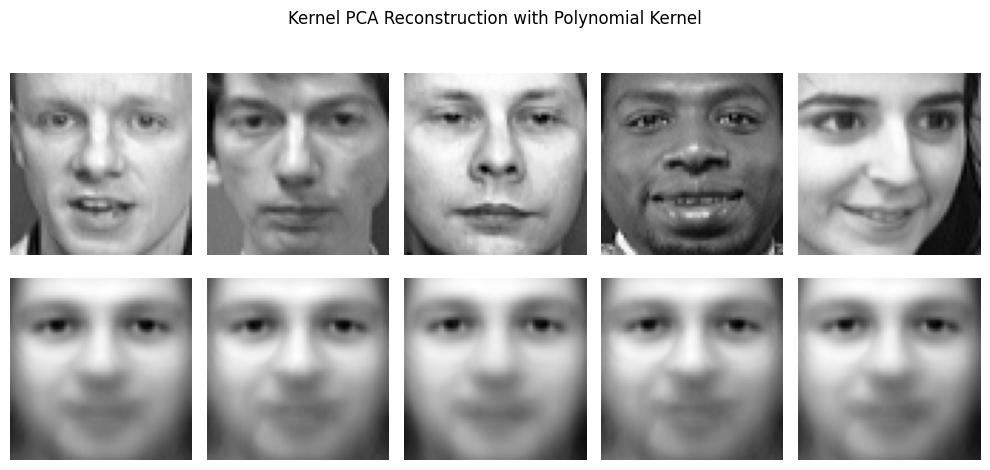

In [14]:
kpca_poly = KernelPCA(
    n_components=100,
    kernel='poly',
    degree=3,
    fit_inverse_transform=True,
    gamma=0.001,
    coef0=1,
    random_state=42
)

X_kpca_poly = kpca_poly.fit_transform(X)
X_kpca_poly_reconstructed = kpca_poly.inverse_transform(X_kpca_poly)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for j in range(5):
    axes[0, j].imshow(images[j], cmap='gray')
    axes[0, j].axis('off')

axes[0, 0].set_ylabel("Original")

for j in range(5):
    axes[1, j].imshow(X_kpca_poly_reconstructed[j].reshape(64, 64), cmap='gray')
    axes[1, j].axis('off')

axes[1, 0].set_ylabel("Poly KPCA")

plt.suptitle('Kernel PCA Reconstruction with Polynomial Kernel')
plt.tight_layout()
plt.show()

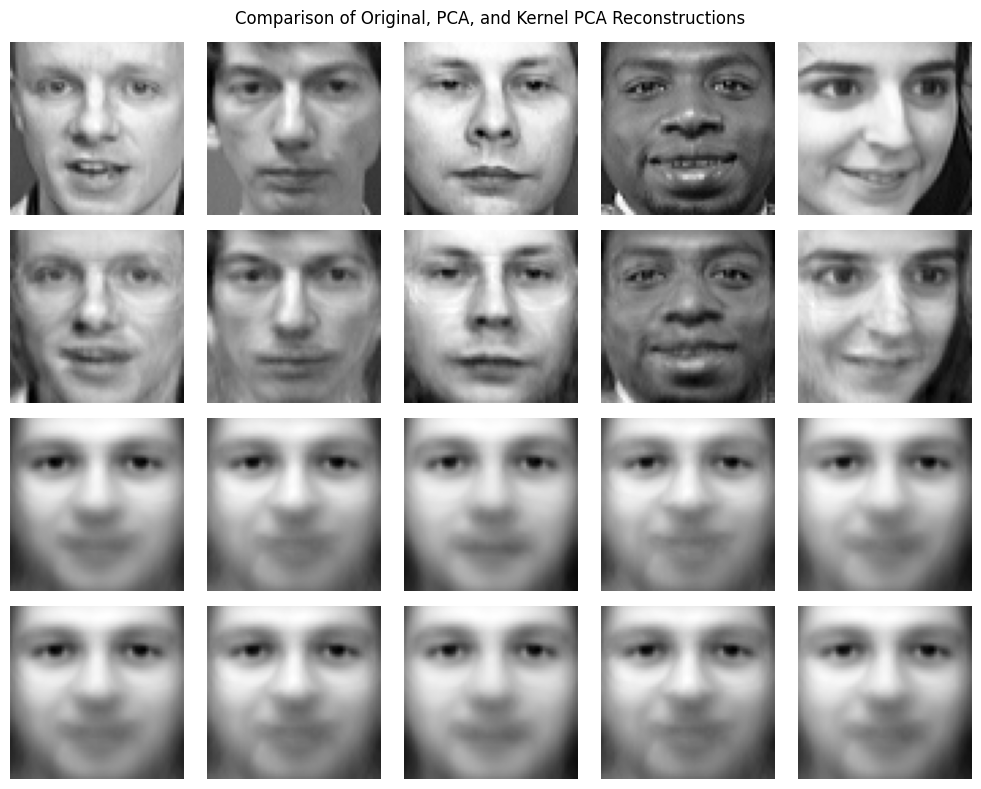

In [15]:
pca_100 = PCA(n_components=100, whiten=True, random_state=42)
X_pca_100 = pca_100.fit_transform(X)
X_pca_100_reconstructed = pca_100.inverse_transform(X_pca_100)

fig, axes = plt.subplots(4, 5, figsize=(10, 8))

titles = ["Original", "PCA 100", "RBF KPCA 100", "Poly KPCA 100"]

for j in range(5):
    axes[0, j].imshow(images[j], cmap='gray')
    axes[0, j].axis('off')

    axes[1, j].imshow(X_pca_100_reconstructed[j].reshape(64, 64), cmap='gray')
    axes[1, j].axis('off')

    axes[2, j].imshow(X_kpca_rbf_reconstructed[j].reshape(64, 64), cmap='gray')
    axes[2, j].axis('off')

    axes[3, j].imshow(X_kpca_poly_reconstructed[j].reshape(64, 64), cmap='gray')
    axes[3, j].axis('off')

for i, title in enumerate(titles):
    axes[i, 0].set_ylabel(title)

plt.suptitle('Comparison of Original, PCA, and Kernel PCA Reconstructions')
plt.tight_layout()
plt.show()

Part 4: Questions & Analysis

1. The reconstruction quality increases as the number of principal components increases. With only 10 principal components, the image reconstruction is able to preserve the general shape of the face, but the details are blurry or in some cases missing entirely. When 50 principal components are used, the images are much less blurry and more facial features are distinguishable. With 100 components, the image reconstruction looks closest to the original images.

2. Standard PCA is best for capturing linear structures because it is designed to capture linear relationships. Kernel PCA is designed to identify nonlinear structures which makes it a better choice when needing to capture nonlinear structures. Kernel PCA is better at modeling the more complex relationships that might be present in a dataset.

3. In this experiment, the standard PCA performed better at preserving the identity and facial features of the images at low dimensionality. Even thought the dimansionality was low and as a result the images were blurry with slightly unclear facial features, the Kernel PCA still performed worse as it generated images that were even more blurred and indistinguishable compared to the standard PCA.

4. Standard PCA has a lower computational cost as it solely focuses on capturing linear relationships. It is easier to interpret as well when compared to the Kernel PCA. The Kernel PCA is more complex due to its ability to capture nonlinear patterns, and because of this, it also has a higher computational cost as well as a lower interpretability.